In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=40).ds.elevation


In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [6]:
extent =[100,160,-69,-65.2]
extent_mertz =[138.5,143,-67,-65.6]
extent_vcbay = [106,114,-70,-65.2]
extent_voyeykov = [121,128,-70,-65.4]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


In [7]:
# set up lines of constant density

tlims = [-2.1,0.4]
slims = [32.9,34.9]
sig0_n = 100
temprange = np.linspace(tlims[0],tlims[1],sig0_n)
psalrange = np.linspace(slims[0],slims[1],sig0_n)

sig0range = np.zeros((sig0_n,sig0_n))
for i,t in enumerate(temprange):
    for j,s in enumerate(psalrange):
        sig0range[i,j]=gsw.sigma0(s,gsw.CT_from_t(s,t,0))


In [8]:


def find_salinity_for_temperture(t,yn):
    def density_difference(s):
        return gsw.density.sigma0(s, t) - yn

    return np.round(root_scalar(density_difference, bracket=(32,37), method='brentq').root,3)

s_yn2800 = [find_salinity_for_temperture(t,28) for t in temprange]
s_yn2755 = [find_salinity_for_temperture(t,27.55) for t in temprange]
s_yn2770 = [find_salinity_for_temperture(t,27.70) for t in temprange]


In [9]:
# setup
# on/off shelf
# with/without trend
# local/widespread region
# months before/after

<GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

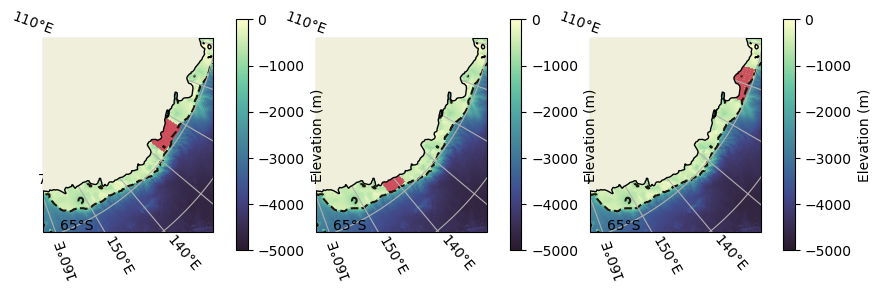

In [10]:
shelf = Region('EA Shelf',extent,elevation_,min_elevation=-1000)
voyeykov = Region('Voyeykov',extent_voyeykov)
mertz = Region('Mertz',extent_mertz)
vcbay = Region('Vincennes Bay',extent_vcbay)
fig, ax = plt.subplots(1,3,figsize=(10,3),subplot_kw={'projection':ccrs.SouthPolarStereo()})
voyeykov.plot_region(ax=ax[0],extent=extent)
mertz.plot_region(ax=ax[1],extent=extent)
vcbay.plot_region(ax=ax[2],extent=extent)

In [11]:
meop_voyeykov=MEOP(extent=extent_voyeykov)
meop_voyeykov.load_profiles()


100%|██████████| 33/33 [00:08<00:00,  3.85it/s]


In [12]:
meop_mertz=MEOP(extent=extent_mertz)
meop_mertz.load_profiles()

100%|██████████| 81/81 [02:19<00:00,  1.73s/it]


In [13]:
meop_vcbay=MEOP(extent=extent_vcbay)
meop_vcbay.load_profiles()

100%|██████████| 72/72 [01:20<00:00,  1.12s/it]


In [14]:
meop=MEOP(extent=extent)
meop.load_profiles()

 21%|██        | 41/193 [00:53<03:17,  1.30s/it]

100%|██████████| 193/193 [04:00<00:00,  1.25s/it]


In [15]:
sla_shelf = shelf.crop_da(sla)

In [18]:
meop.df

,latitude,longitude,filename,temperature,salinity,gph
time,,,,,,
2012-03-23 23:40:00,-66.4295,110.2223,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.161478
2012-03-24 01:30:00,-66.4146,110.2967,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.164348
2012-03-24 07:10:00,-66.4237,110.3350,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.164398
2012-03-24 21:10:00,-66.4869,109.9853,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.167724
2012-03-25 07:10:00,-66.4959,110.1135,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.165861
...,...,...,...,...,...,...
2019-06-08 07:49:59,-66.6608,141.3027,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.013696
2019-06-08 23:09:59,-66.6508,141.3139,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.027960
2019-06-09 15:50:00,-66.6525,141.3284,/nfs/b0133/eejco/data/MEOP_2024/media/disk2/ro...,[[<xarray.DataArray 'TEMP_ADJUSTED' ()> Size: ...,[[<xarray.DataArray 'PSAL_ADJUSTED' ()> Size: ...,0.028732


In [16]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims)

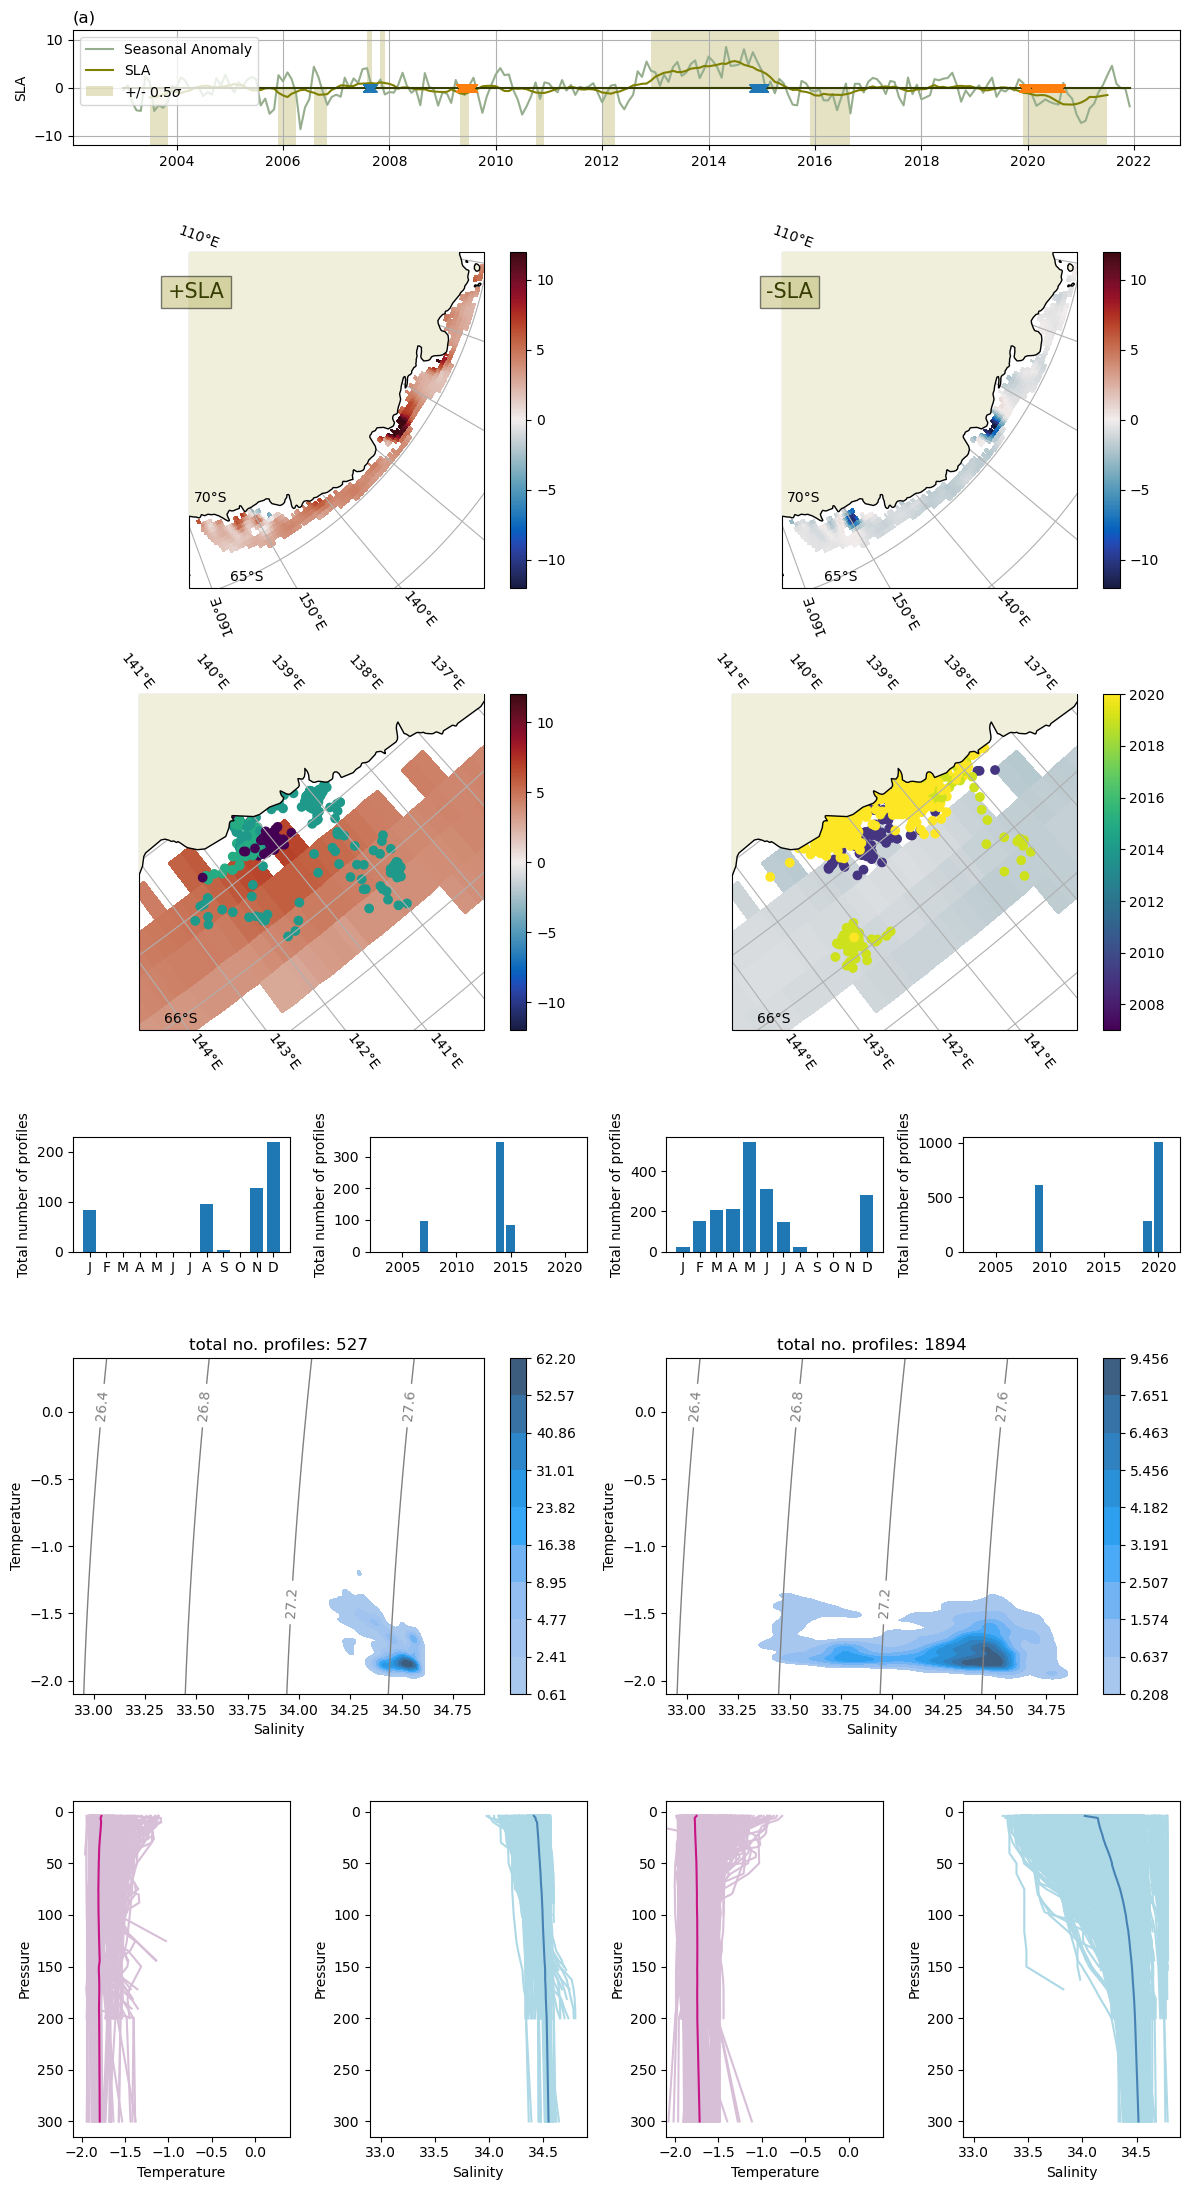

In [17]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()



In [34]:
background_data = sanom(sla_shelf).mean(['latitude','longitude'])
background_data = utls.detrend_dim(background_data,'time')
idx_data = background_data.rolling(time=12,center=True).mean('time')

cmp = Composite(idx_data,'SLA')
cmp.add_meop(meop_mertz,tlims=tlims,slims=slims,lag=6)

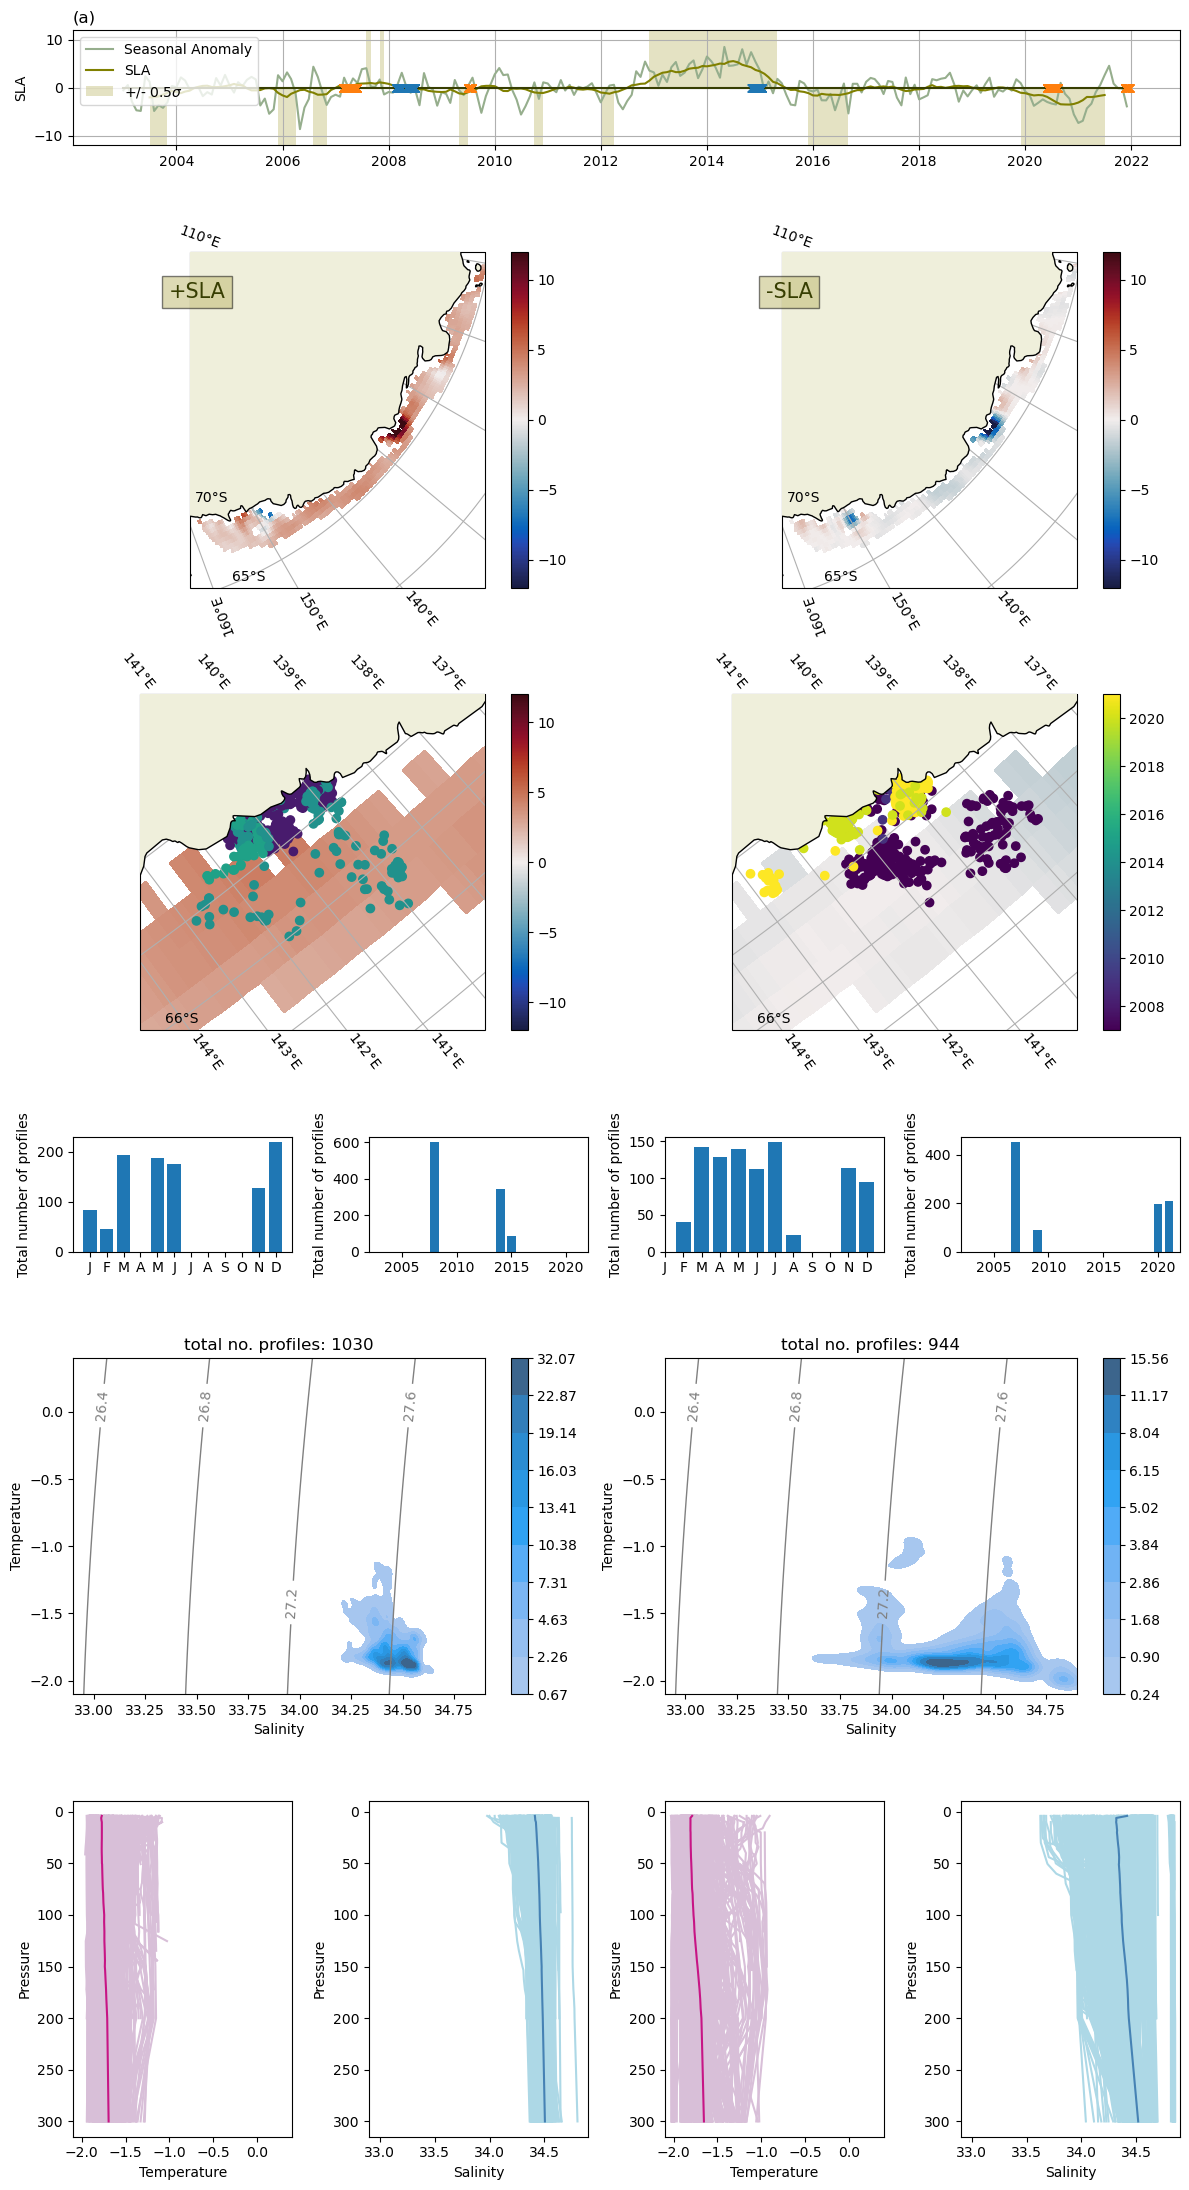

In [35]:
fig = plt.figure(figsize=(12,22))
gs = fig.add_gridspec(10,4)

# FIG1: SLA/SAM TIMESERIES
ax1 = fig.add_subplot(gs[0, :])

cmp.composite_timeseries(ax1,background_data,bg_name='Seasonal Anomaly')
# FIG2: SLA MAP
ax2 = fig.add_subplot(gs[1:3, 0:2],projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(gs[1:3, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax2,ax3],sanom(shelf.crop_da(sla)),'SLA',12,extent,label_loc=[130,-80])

# FIG3: SLA closeup
ax4 = fig.add_subplot(gs[3:5, 0:2],projection=ccrs.SouthPolarStereo())
ax5 = fig.add_subplot(gs[3:5, 2:4],projection=ccrs.SouthPolarStereo())
cmp.posneg_map([ax4,ax5],sanom(shelf.crop_da(sla)),'SLA',12,extent_mertz,add_profiles=True)

n = 5
cmp.ts_freq_plot([ 
    fig.add_subplot(gs[n,0]),
    fig.add_subplot(gs[n,1]),
    fig.add_subplot(gs[n,2]),
    fig.add_subplot(gs[n,3]),
])

# FIG4: TS DESNITY
n = 6
cmp.ts_density([
    fig.add_subplot(gs[n:n+2,0:2]),
    fig.add_subplot(gs[n:n+2,2:4])
    ])

# FIG5: TS PROFILES
n = 8
ax8 = fig.add_subplot(gs[8:10,0])
ax9 = fig.add_subplot(gs[8:10,1])
ax10 = fig.add_subplot(gs[8:10,2])
ax11 = fig.add_subplot(gs[8:10,3])
cmp.ts_profiles([ax8,ax9,ax10,ax11])

plt.tight_layout()

